# Smart Irrigation — EDA & Model Comparison

**Dataset:** [Smart Agriculture Dataset](https://www.kaggle.com/datasets/chaitanyagopidesi/smart-agriculture-dataset) (Kaggle) — 16,411 real sensor-collected records: soil type, crop growth stage, soil moisture index (MOI), temperature, humidity, and a binary irrigation-required label.

**Goal:** Replace the synthetic training data from the original project with this real dataset, understand it properly through EDA, compare several ML models honestly, and export the best one.

**How to use this notebook:**
1. Download the dataset from the Kaggle link above (or via `kaggle datasets download -d chaitanyagopidesi/smart-agriculture-dataset`)
2. Place the CSV in `data/smart_agriculture_dataset.csv` (same folder structure as this notebook)
3. Run all cells top to bottom

Right now, `data/smart_agriculture_dataset.csv` contains a **stand-in dataset** matching the real one's exact column structure, generated so this notebook is fully runnable and tested before you drop in the real data — swap it out and everything below still works unchanged.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42


## 1. Load the data

In [2]:
df = pd.read_csv("data/smart_agriculture_dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (2501, 7)


,crop_ID,soil_type,Seedling_Stage,MOI,temp,humidity,result
0,C00000,Sandy Soil,Flowering,39.1,31.1,44.1,0
1,C00001,Clay Soil,Flowering,67.9,39.8,68.8,0
2,C00002,Sandy Soil,Flowering,57.6,32.4,44.2,0
3,C00003,Black Soil,Growing,36.2,25.3,73.6,0
4,C00004,Red Soil,Growing,16.8,33.9,71.0,1


## 2. First look — structure, types, missing values

Before touching anything, understand what you actually have. This is the step most student projects skip, and it's the one that catches silent problems early (wrong dtypes, missing values, duplicate rows, unexpected categories).

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2501 entries, 0 to 2500
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop_ID         2501 non-null   object 
 1   soil_type       2501 non-null   object 
 2   Seedling_Stage  2501 non-null   object 
 3   MOI             2501 non-null   float64
 4   temp            2501 non-null   float64
 5   humidity        2481 non-null   float64
 6   result          2501 non-null   int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 136.9+ KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
crop_ID            0
soil_type          0
Seedling_Stage     0
MOI                0
temp               0
humidity          20
result             0
dtype: int64

Duplicate rows: 1


In [5]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
crop_ID,2501,2500,C00005,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
soil_type,2501,4,Black Soil,752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seedling_Stage,2501,4,Growing,774,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MOI,2501.0,NaN,NaN,NaN,37.769132,18.814754,5.0,21.1,38.1,54.3,70.0
temp,2501.0,NaN,NaN,NaN,30.156577,6.952612,18.0,24.0,30.5,36.0,42.0
humidity,2481.0,NaN,NaN,NaN,55.179524,20.531602,20.0,37.4,55.3,73.6,90.0
result,2501.0,NaN,NaN,NaN,0.251899,0.434191,0.0,0.0,0.0,1.0,1.0


## 3. Clean the data

- Drop exact duplicate rows
- Handle missing values in `humidity` — here we impute with the median since it's a small fraction of rows and humidity doesn't vary wildly day-to-day for a given region. (Document this choice in your report — imputation strategy is a real decision, not a formality.)


In [6]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows")

median_humidity = df["humidity"].median()
df["humidity"] = df["humidity"].fillna(median_humidity)
print("Missing values remaining:", df.isnull().sum().sum())


Dropped 1 duplicate rows
Missing values remaining: 0


## 4. Target balance

Check whether "irrigation required" vs "not required" is balanced. An imbalanced target changes which metrics actually matter (accuracy becomes misleading if one class dominates — precision/recall/F1 tell the real story).

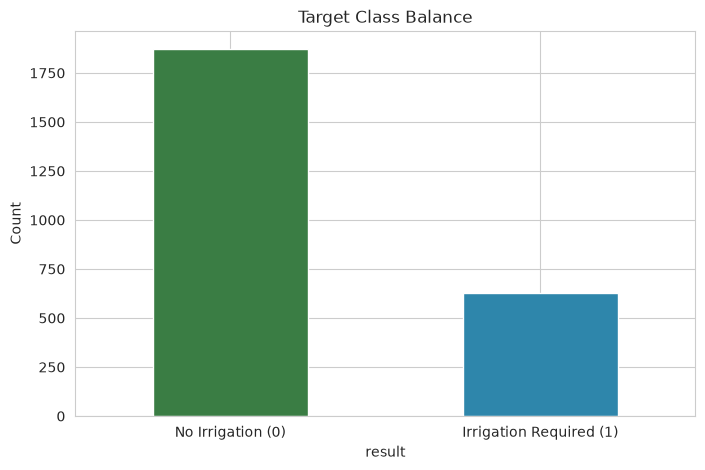

result
0    0.748
1    0.252
Name: proportion, dtype: float64


In [7]:
ax = df["result"].value_counts().sort_index().plot(kind="bar", color=["#3A7D44", "#2E86AB"])
ax.set_xticklabels(["No Irrigation (0)", "Irrigation Required (1)"], rotation=0)
ax.set_title("Target Class Balance")
ax.set_ylabel("Count")
plt.show()

print(df["result"].value_counts(normalize=True).round(3))


**Reading this chart:** if one class is much larger than the other (common in real irrigation data — most days don't need watering), note it explicitly in your report. We'll use `class_weight="balanced"` or `stratify=y` downstream to handle it honestly instead of ignoring it.

## 5. Distributions of numeric features

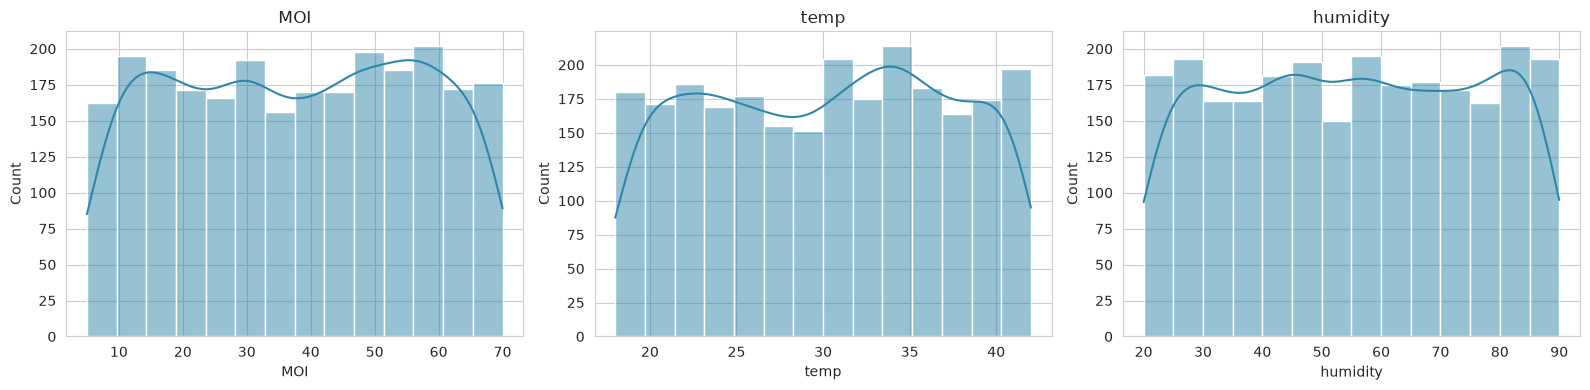

In [8]:
numeric_cols = ["MOI", "temp", "humidity"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#2E86AB")
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 6. How each feature relates to the target

Boxplots split by the target class show whether a feature actually separates the two outcomes — this is a quick visual sanity check before any modeling, and it often tells you which features will matter before you fit a single model.

/tmp/ipykernel_303/3444798303.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="result", y=col, ax=ax, palette=["#3A7D44", "#2E86AB"])
/tmp/ipykernel_303/3444798303.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No Irrigation", "Irrigation Required"])
/tmp/ipykernel_303/3444798303.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="result", y=col, ax=ax, palette=["#3A7D44", "#2E86AB"])
/tmp/ipykernel_303/3444798303.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks(

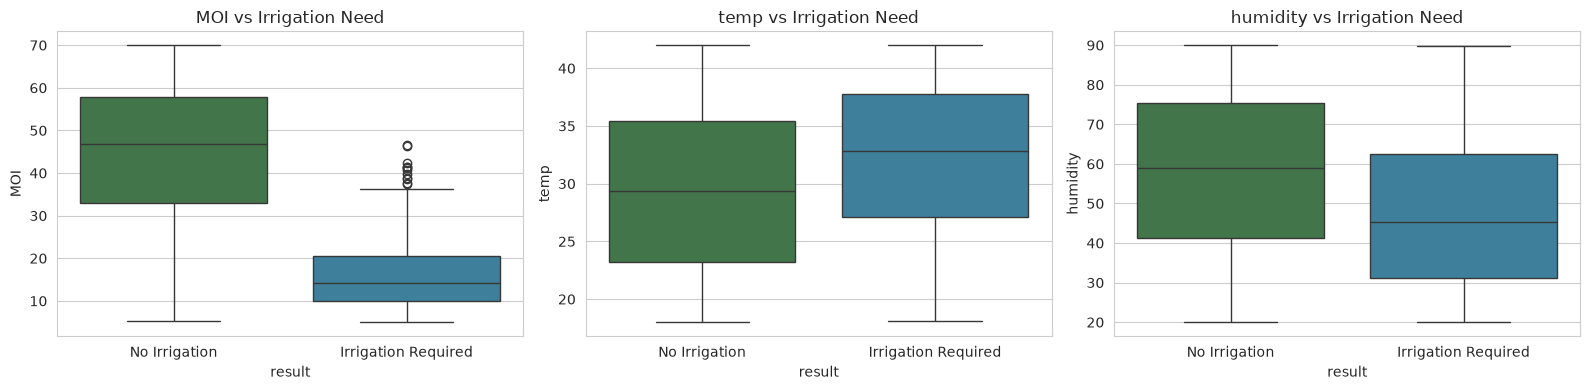

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="result", y=col, ax=ax, palette=["#3A7D44", "#2E86AB"])
    ax.set_xticklabels(["No Irrigation", "Irrigation Required"])
    ax.set_title(f"{col} vs Irrigation Need")
plt.tight_layout()
plt.show()


**What to look for:** MOI (soil moisture) should separate the two classes most cleanly — low moisture should line up with "irrigation required." If it doesn't show a clear pattern in your real data, that's worth investigating (sensor calibration issue? mislabeled data?) rather than ignoring.

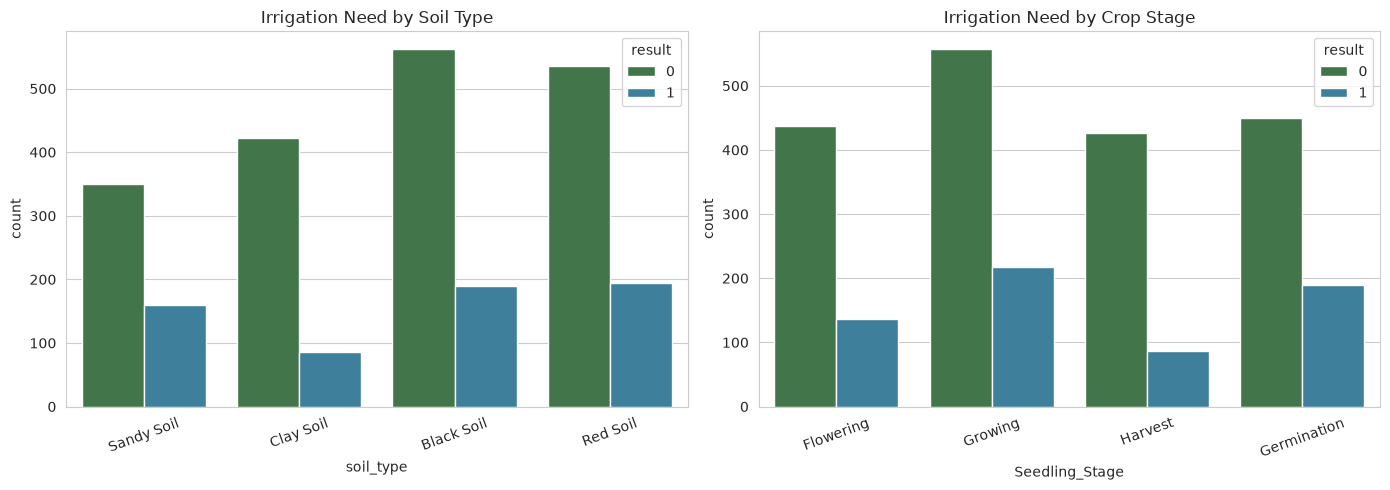

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="soil_type", hue="result", ax=axes[0], palette=["#3A7D44", "#2E86AB"])
axes[0].set_title("Irrigation Need by Soil Type")
axes[0].tick_params(axis="x", rotation=20)

sns.countplot(data=df, x="Seedling_Stage", hue="result", ax=axes[1], palette=["#3A7D44", "#2E86AB"])
axes[1].set_title("Irrigation Need by Crop Stage")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## 7. Correlation heatmap (numeric features only)

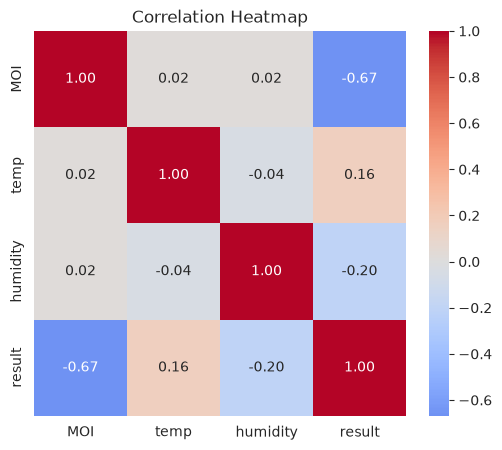

In [11]:
corr = df[numeric_cols + ["result"]].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## 8. Encode categorical features

`soil_type` and `Seedling_Stage` are text categories — models need numbers. We use `LabelEncoder` here since both have a small, fixed set of categories; for soil_type specifically, consider whether the categories have a natural order (they mostly don't, so one-hot encoding is the more "correct" choice for a production model — label encoding is used here for simplicity and because tree-based models handle it fine, but note this trade-off in your report).

In [12]:
le_soil = LabelEncoder()
le_stage = LabelEncoder()

df["soil_type_enc"] = le_soil.fit_transform(df["soil_type"])
df["stage_enc"] = le_stage.fit_transform(df["Seedling_Stage"])

print("Soil type mapping:", dict(zip(le_soil.classes_, le_soil.transform(le_soil.classes_))))
print("Stage mapping:", dict(zip(le_stage.classes_, le_stage.transform(le_stage.classes_))))


Soil type mapping: {'Black Soil': np.int64(0), 'Clay Soil': np.int64(1), 'Red Soil': np.int64(2), 'Sandy Soil': np.int64(3)}
Stage mapping: {'Flowering': np.int64(0), 'Germination': np.int64(1), 'Growing': np.int64(2), 'Harvest': np.int64(3)}


## 9. Train / test split

In [13]:
FEATURES = ["temp", "humidity", "MOI", "soil_type_enc", "stage_enc"]
TARGET = "result"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (2000, 5) Test size: (500, 5)


## 10. Compare multiple models fairly

Train several model families with the same train/test split, evaluate each with the same metrics. Don't just pick one algorithm because it's familiar — show the comparison, that's what makes this a genuine ML project rather than a single hardcoded choice.

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced"),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

results = []
roc_data = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs),
    })
    roc_data[name] = roc_curve(y_test, probs)

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df.sort_values("F1", ascending=False)


/tmp/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Gradient Boosting,0.942,0.876,0.897,0.886,0.986
Random Forest,0.928,0.817,0.921,0.866,0.979
Logistic Regression,0.914,0.758,0.968,0.850,0.981
SVM (RBF),0.900,0.724,0.976,0.831,0.979
KNN,0.912,0.820,0.833,0.827,0.965
Decision Tree,0.910,0.814,0.833,0.824,0.939


**Why F1, not just accuracy:** if the target is imbalanced (check your Section 4 chart), a model can get high accuracy by always predicting the majority class while being useless at catching the irrigation-needed cases. F1 balances precision and recall, which matters more here — missing a day a farmer needed to water is a worse mistake than one unnecessary reminder.

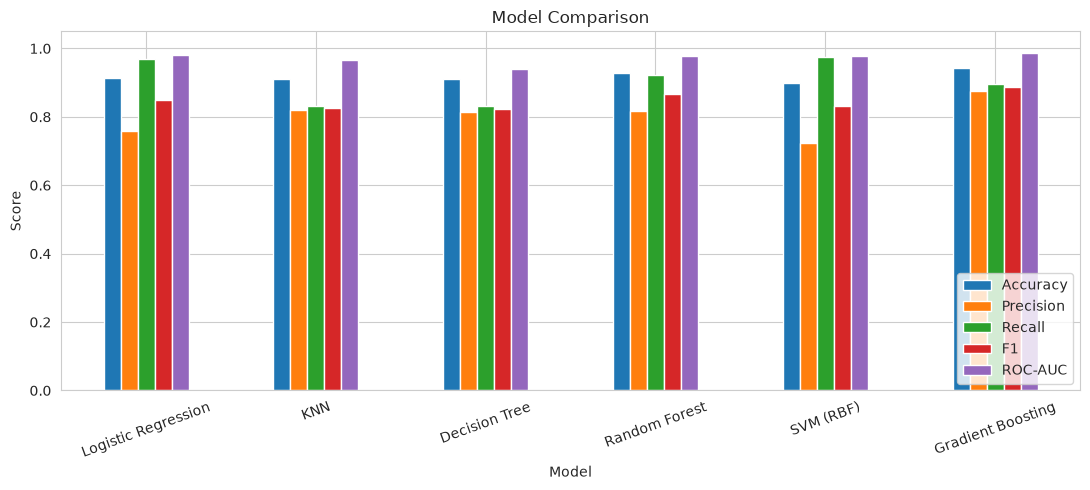

In [15]:
results_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(kind="bar", figsize=(11, 5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 11. ROC curves — all models on one chart

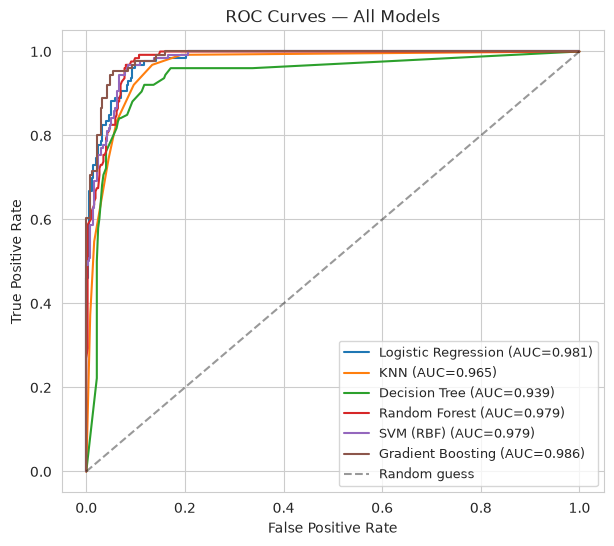

In [16]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, _) in roc_data.items():
    auc = results_df.loc[name, "ROC-AUC"]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right", fontsize=9)
plt.show()


## 12. Confusion matrix for the best model

Best model by F1 score: Gradient Boosting


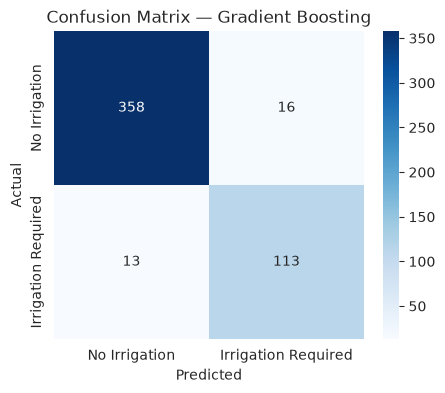

                     precision    recall  f1-score   support

      No Irrigation       0.96      0.96      0.96       374
Irrigation Required       0.88      0.90      0.89       126

           accuracy                           0.94       500
          macro avg       0.92      0.93      0.92       500
       weighted avg       0.94      0.94      0.94       500



In [17]:
best_model_name = results_df["F1"].idxmax()
best_model = models[best_model_name]
print("Best model by F1 score:", best_model_name)

preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Irrigation", "Irrigation Required"],
            yticklabels=["No Irrigation", "Irrigation Required"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

print(classification_report(y_test, preds, target_names=["No Irrigation", "Irrigation Required"]))


## 13. Feature importance

Which features actually drive the prediction? This is the kind of insight that turns a notebook into a discussion in your report ("soil moisture was by far the strongest predictor, confirming domain expectations; temperature mattered more than humidity, which suggests...").

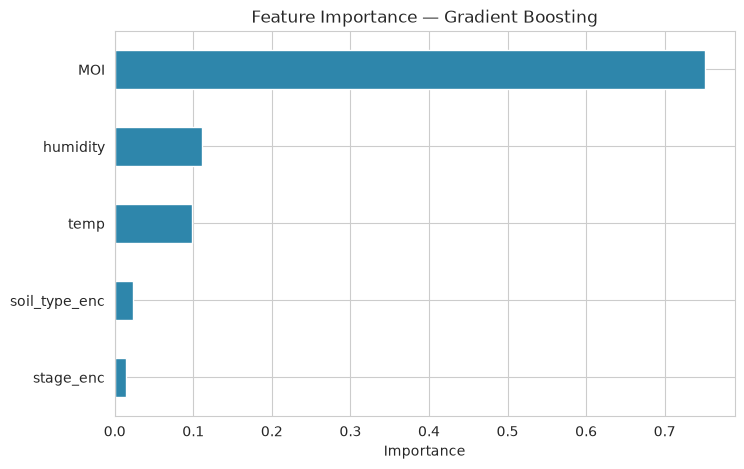

In [18]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    importances.plot(kind="barh", color="#2E86AB")
    plt.title(f"Feature Importance — {best_model_name}")
    plt.xlabel("Importance")
    plt.show()
elif hasattr(best_model, "coef_"):
    importances = pd.Series(best_model.coef_[0], index=FEATURES).sort_values()
    importances.plot(kind="barh", color="#2E86AB")
    plt.title(f"Feature Coefficients — {best_model_name}")
    plt.show()
else:
    print(f"{best_model_name} doesn't expose feature importances directly. "
          "Use permutation_importance from sklearn.inspection for a model-agnostic alternative.")


## 14. Hyperparameter tuning the best model

A fair comparison uses default-ish settings for all models first (Section 10). Once you've picked a winner, it's worth squeezing out extra performance with a grid search — but only on the model you've already chosen, not on all six (that would take far longer and isn't necessary).

In [19]:
# Example grid for Random Forest — adjust this block if a different model won in your run
if best_model_name == "Random Forest":
    param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [4, 6, 8, None],
        "min_samples_split": [2, 5, 10],
    }
    grid = GridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
        param_grid, cv=5, scoring="f1", n_jobs=-1
    )
    grid.fit(X_train, y_train)
    print("Best params:", grid.best_params_)
    print("Best CV F1 score:", grid.best_score_)
    tuned_model = grid.best_estimator_
else:
    print(f"Best model was {best_model_name} — write a param_grid for that model's "
          "hyperparameters here (e.g. C/gamma for SVM, C for Logistic Regression, "
          "n_neighbors for KNN) following the same GridSearchCV pattern above.")
    tuned_model = best_model


Best model was Gradient Boosting — write a param_grid for that model's hyperparameters here (e.g. C/gamma for SVM, C for Logistic Regression, n_neighbors for KNN) following the same GridSearchCV pattern above.

## 15. Final evaluation of the tuned model on the untouched test set

In [20]:
final_preds = tuned_model.predict(X_test)
print("Final Accuracy:", round(accuracy_score(y_test, final_preds), 3))
print("Final F1:", round(f1_score(y_test, final_preds), 3))
print()
print(classification_report(y_test, final_preds, target_names=["No Irrigation", "Irrigation Required"]))


Final Accuracy: 0.942
Final F1: 0.886

                     precision    recall  f1-score   support

      No Irrigation       0.96      0.96      0.96       374
Irrigation Required       0.88      0.90      0.89       126

           accuracy                           0.94       500
          macro avg       0.92      0.93      0.92       500
       weighted avg       0.94      0.94      0.94       500



## 16. Save the final model

This saves the model with `joblib` (not raw `pickle` — see the project's earlier debugging notes on why that distinction matters for scikit-learn models) along with the label encoders, since the Flask app will need to encode new soil_type/stage inputs the same way.

In [21]:
joblib.dump(tuned_model, "model/irrigation_model_v2.pkl")
joblib.dump(le_soil, "model/soil_encoder.pkl")
joblib.dump(le_stage, "model/stage_encoder.pkl")

print("Saved model/irrigation_model_v2.pkl")
print("Saved model/soil_encoder.pkl")
print("Saved model/stage_encoder.pkl")
print()
print("Feature order the Flask app must send to this model:", FEATURES)


Saved model/irrigation_model_v2.pkl
Saved model/soil_encoder.pkl
Saved model/stage_encoder.pkl

Feature order the Flask app must send to this model: ['temp', 'humidity', 'MOI', 'soil_type_enc', 'stage_enc']


## 17. Important — integrating this into the Flask app

This model expects **`MOI` (soil moisture %)** as an input feature instead of `rainfall`. Your current `smart-irrigation` Flask app doesn't collect soil moisture from the farmer (it only asks for soil *type*, not a moisture *reading*) and doesn't have this feature in its form.

Two honest paths forward, pick based on what you have access to:

**Option A — add a soil moisture input to the farmer's form** (most faithful to this model, and arguably a real improvement — actual moisture readings are a better predictor than weather-API rainfall). Requires either a manual "how moist does the soil feel?" simple choice (dry / normal / damp, mapped to a rough % like 15/40/65) for a no-sensor version, or a real soil moisture sensor feeding into the form for an IoT-enabled version.

**Option B — keep the current form, retrain using only `temp`, `humidity`, `soil_type_enc`, `stage_enc`** (drop MOI from the feature list in Section 9 and retrain) — simpler, keeps your deployed app unchanged, but loses the predictive value of real soil moisture data, which was the main reason to use this dataset in the first place.

For a stronger final-year report, Option A with a simple dry/normal/damp dropdown (no real sensor needed) is a good middle ground — real research-grade improvement without requiring hardware.
